# LSTM Car Registrations Forecast
This notebook builds an LSTM model to forecast car registrations using a 12-step lookback window with MinMax scaling applied after train-test split.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

## Load the CSV Dataset

In [2]:
# Load the dataset
df = pd.read_csv('car_registrations.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

Dataset shape: (316, 2)

First 5 rows:
      Date  Car_Registrations
0  2000-01              26064
1  2000-02              23929
2  2000-03              32057
3  2000-04              29513
4  2000-05              31176

Last 5 rows:
        Date  Car_Registrations
311  2025-12              96970
312  2026-01              67995
313  2026-02              56690
314  2026-03              67846
315  2026-04              77869


## Parse Dates and Sort Data

In [3]:
# Convert date column to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total months: {len(df)}")

Date range: 2000-01-01 00:00:00 to 2026-04-01 00:00:00
Total months: 316


## Create Time Series Index and Target

In [4]:
# Set date as index and extract target column
df.set_index('Date', inplace=True)
data = df['Car_Registrations'].values.reshape(-1, 1)
print(f"Data shape: {data.shape}")

Data shape: (316, 1)


## Split Data into Train and Test (Last 12 Months)

In [5]:
# Split into train (all but last 12) and test (last 12 months)
test_size = 12
train_data = data[:-test_size]
test_data = data[-test_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Train range: {len(train_data)} months")
print(f"Test range: {len(test_data)} months")

Train data shape: (304, 1)
Test data shape: (12, 1)
Train range: 304 months
Test range: 12 months


## Scale Data with MinMaxScaler After Split

In [6]:
# Create scaler and fit on training data only
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(f"Scaled train shape: {train_scaled.shape}")
print(f"Scaled test shape: {test_scaled.shape}")
print(f"Scaler min: {scaler.data_min_[0]:.2f}, max: {scaler.data_max_[0]:.2f}")

Scaled train shape: (304, 1)
Scaled test shape: (12, 1)
Scaler min: 129.00, max: 84429.00


## Create LSTM Input Sequences

In [ ]:
import numpy as np

def create_sequences(data, lookback=12):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0:1]) 
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 12

X_train, y_train = create_sequences(train_scaled, lookback)

test_extended = np.vstack((train_scaled[-lookback:], test_scaled))
X_test, y_test = create_sequences(test_extended, lookback)

print(f"X_train shape: {X_train.shape}") # Output: (samples, 12, 1)
print(f"X_test shape: {X_test.shape}")   # Output: (len(test_scaled), 12, 1)

X_train shape: (292, 12, 1)
X_test shape: (12, 12, 1)


## Build the LSTM Model

In [8]:
model = Sequential([
    LSTM(
        16,
        input_shape=(
            lookback,
            1
        )
    ),

    Dense(
        8,
        activation='relu'
    ),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

print("Model Architecture:")
print(model.summary())

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

None


## Train the Model

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

print("Training the LSTM model with walk-forward validation...")

# Define the Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

# Build a fresh compiled model for each fold

def create_model(lookback=12):
    model = Sequential([
        LSTM(16, input_shape=(lookback, 1)),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


def walk_forward_validation(scaled_data, lookback=12, val_size=12, n_splits=3):
    total_len = len(scaled_data)
    max_splits = (total_len - lookback - val_size) // val_size
    if max_splits < 1:
        raise ValueError("Not enough data for walk-forward validation with the given parameters.")

    n_splits = min(n_splits, max_splits)
    metrics = []

    for split in range(n_splits):
        train_end = lookback + (split + 1) * val_size
        val_start = train_end
        val_end = val_start + val_size

        train_window = scaled_data[:train_end]
        val_window = scaled_data[val_start:val_end]

        X_train_w, y_train_w = create_sequences(train_window, lookback)
        X_val_w, y_val_w = create_sequences(
            np.vstack((train_window[-lookback:], val_window)),
            lookback
        )

        fold_model = create_model(lookback)
        fold_model.fit(
            X_train_w,
            y_train_w,
            epochs=100,
            batch_size=16,
            validation_data=(X_val_w, y_val_w),
            callbacks=[early_stopping],
            shuffle=False,
            verbose=0
        )

        y_val_pred = fold_model.predict(X_val_w, verbose=0)
        mse = mean_squared_error(y_val_w, y_val_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_val_w, y_val_pred)
        metrics.append((mse, rmse, r2))

        print(
            f"Fold {split + 1}: train_end={train_end}, val_end={val_end}, "
            f"MSE={mse:.6f}, RMSE={rmse:.6f}, R²={r2:.6f}"
        )

    return metrics

metrics = walk_forward_validation(train_scaled, lookback=lookback, val_size=24, n_splits=3)

mse_values = [m[0] for m in metrics]
rmse_values = [m[1] for m in metrics]
r2_values = [m[2] for m in metrics]

print("\nWalk-forward validation summary:")
print(f"Average MSE:  {np.mean(mse_values):.6f}")
print(f"Average RMSE: {np.mean(rmse_values):.6f}")
print(f"Average R²:   {np.mean(r2_values):.6f}")

print("\nTraining final model on the full training set...")
model = create_model(lookback)
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

print("\nTraining completed!")

Training the LSTM model with walk-forward validation...
Epoch 94: early stopping
Restoring model weights from the end of the best epoch: 64.
Fold 1: train_end=36, val_end=60, MSE=0.003958, RMSE=0.062912, R²=0.065032
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.
Fold 2: train_end=60, val_end=84, MSE=0.286464, RMSE=0.535224, R²=-51.434817
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.
Fold 3: train_end=84, val_end=108, MSE=0.273273, RMSE=0.522755, R²=-51.289256

Walk-forward validation summary:
Average MSE:  0.187899
Average RMSE: 0.373630
Average R²:   -34.219680

Training final model on the full training set...
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3277
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2251
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1168
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0232 
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s

## Evaluate with MSE, RMSE, and R2

In [10]:
# Make predictions on test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Calculate metrics on scaled data
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print("=== Metrics on Scaled Data ===")
print(f"MSE (scaled):  {mse_scaled:.6f}")
print(f"RMSE (scaled): {rmse_scaled:.6f}")
print(f"R² (scaled):   {r2_scaled:.6f}")

=== Metrics on Scaled Data ===
MSE (scaled):  0.018162
RMSE (scaled): 0.134768
R² (scaled):   -0.136098


## Inverse Scale Predictions

In [11]:
# Inverse scale predictions and actual values back to original scale
y_pred_original = scaler.inverse_transform(y_pred_scaled)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics on original scale
mse_original = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y_test_original, y_pred_original)

print("=== Metrics on Original Scale ===")
print(f"MSE (original):  {mse_original:.2f}")
print(f"RMSE (original): {rmse_original:.2f}")
print(f"R² (original):   {r2_original:.6f}")

=== Metrics on Original Scale ===
MSE (original):  129071011.85
RMSE (original): 11360.94
R² (original):   -0.136098


## Plot Prediction vs Actual

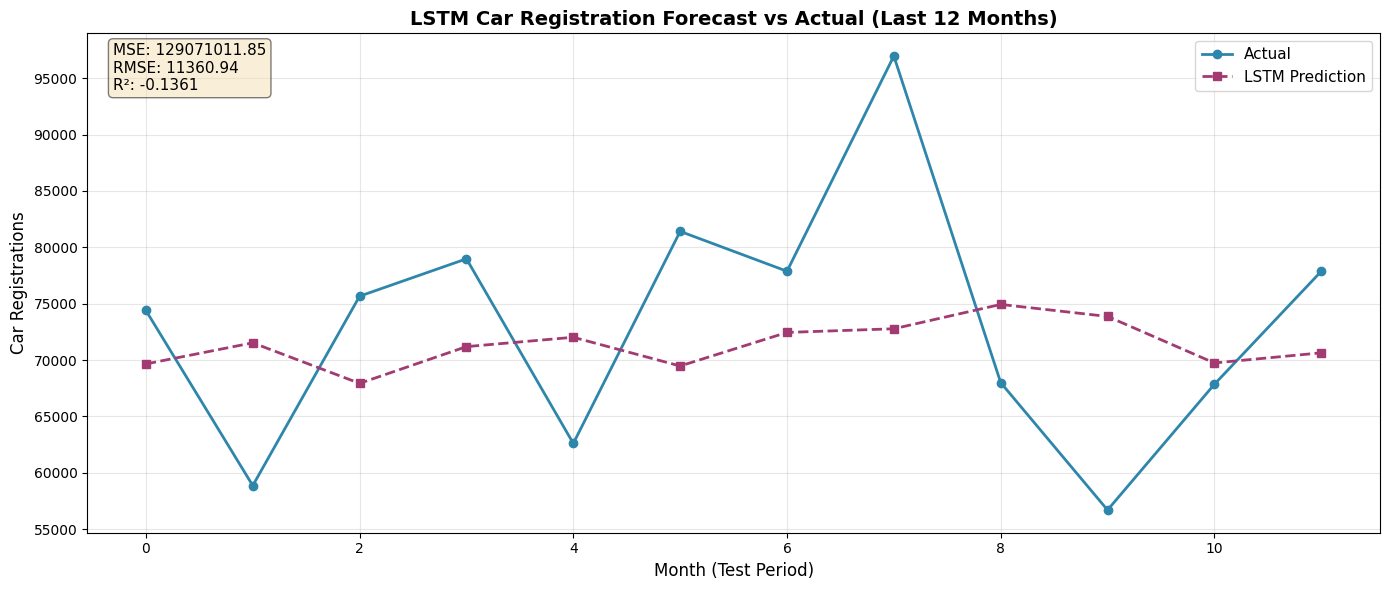


✓ Forecast completed successfully!


In [ ]:
# Create prediction vs actual plot
plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(range(len(y_test_original)), y_test_original, marker='o', linestyle='-', 
         linewidth=2, label='Actual', color='#2E86AB', markersize=6)

# Plot predictions
plt.plot(range(len(y_pred_original)), y_pred_original, marker='s', linestyle='--', 
         linewidth=2, label='LSTM Prediction', color='#A23B72', markersize=6)

plt.title('LSTM Car Registration Forecast vs Actual (Last 12 Months)', fontsize=14, fontweight='bold')
plt.xlabel('Month (Test Period)', fontsize=12)
plt.ylabel('Car Registrations', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)

# Add metrics to the plot
metrics_text = f'MSE: {mse_original:.2f}\nRMSE: {rmse_original:.2f}\nR²: {r2_original:.4f}'
plt.text(0.02, 0.98, metrics_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n✓ Forecast completed successfully!")